<a href="https://colab.research.google.com/github/Jmontoyaor/SignalsandSystems-/blob/main/EJERCICIOS_CARPETASSLIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CUADERNO #1

Ahora resulta obvio que tenemos que considerar tres casos con respecto a la superposición de $h(t-\tau)$ y $x(\tau)$

1. $t<0$: sin traslape
2. $0 \leq t < 1$: traslape parcial
3. $t > 0$: traslape completo



**Ejercicio**

En el **cuarto paso**, la evaluación de las integrales de convolución para los tres casos se deja abierta como un ejercicio. Tenga en cuenta que, en el primer caso, no se superponen, es decir que $y(t)=0$ para $t<0$.

%%markdown

# Cálculo teórico de la convolución

Sean las funciones:

- $$x(t)$$: pulso rectangular entre $$t = 0$$ y $$t = 1$$  
- $$h(t) = e^{-t} u(t)$$: exponencial decreciente a partir de $$t = 0$$

La convolución se define como:

$$
y(t) = \int_{-\infty}^{\infty} x(\tau) h(t - \tau) \, d\tau
$$

---

## Caso 1: $$t < 0$$ (sin traslape)

Para $$t < 0$$, la señal $$h(t - \tau)$$ está completamente desplazada a la izquierda de $$x(\tau)$$. No hay superposición.

$$
x(\tau) \cdot h(t - \tau) = 0 \quad \text{para todo } \tau
$$

Entonces:

$$
y(t) = \int_{-\infty}^{\infty} 0 \, d\tau = 0 \quad \text{para } t < 0
$$

---

## Caso 2: $$0 \leq t < 1$$ (traslape parcial)

En este intervalo ocurre superposición parcial. Condiciones de traslape:

- $$x(\tau) \neq 0$$ cuando $$0 \leq \tau \leq 1$$  
- $$h(t - \tau) \neq 0$$ cuando $$\tau \leq t$$

Por lo tanto:

$$
0 \leq \tau \leq t
$$

Calculamos la integral:

$$
y(t) = \int_{0}^{t} e^{-(t - \tau)} \, d\tau
= \int_{0}^{t} e^{-t} e^{\tau} \, d\tau = e^{-t} \int_{0}^{t} e^{\tau} \, d\tau
$$

$$
y(t) = e^{-t} \left[ e^{\tau} \right]_{0}^{t} = e^{-t}(e^{t} - 1) = 1 - e^{-t}
$$

$$
\Rightarrow y(t) = 1 - e^{-t} \quad \text{para } 0 \leq t < 1
$$

---

## Caso 3: $$t \geq 1$$ (traslape completo)

En este caso hay traslape completo. El intervalo de integración es:

$$
0 \leq \tau \leq 1
$$

Entonces:

$$
y(t) = \int_{0}^{1} e^{-(t - \tau)} \, d\tau = e^{-t} \int_{0}^{1} e^{\tau} \, d\tau
$$

$$
y(t) = e^{-t} \left[ e^{\tau} \right]_{0}^{1} = e^{-t}(e - 1)
$$

$$
\Rightarrow y(t) = (e - 1)e^{-t} \quad \text{para } t \geq 1
$$

---

## Resultado final

$$
y(t) =
\begin{cases}
0 & \text{si } t < 0 \\
1 - e^{-t} & \text{si } 0 \leq t < 1 \\
(e - 1)e^{-t} & \text{si } t \geq 1
\end{cases}
$$


CUADERNO #2

**Ejercicio**

* Compare la señal de salida obtenida al resolver la EDO con la obtenida mediante la convolución. Son iguales?
* Compruebe la solución $h(t)$ de la EDO cuando $x(t)=\delta(t)$ de manera manual. Tener en cuenta que $\frac{d}{dt} \epsilon(t) = \delta(t)$.
* Comprobar la solución de la integral de convolución de manera manual. Tener en cuenta las funciones Heaviside.






### **✅ Enunciado:**

**Compare la señal de salida obtenida al resolver la EDO con la obtenida mediante la convolución. ¿Son iguales?**

---



Se tiene el sistema descrito por la ecuación diferencial:

$$
\frac{d}{dt}y(t) + y(t) = x(t)
$$

Con entrada:

$$
x(t) = e^{-2t} \cdot u(t)
$$

Y condiciones iniciales:

$$
y(0^-) = 0
$$





En el código, se resolvió esta EDO en `SymPy` con las condiciones iniciales. La solución obtenida fue:

$$
y_1(t) = \left( e^{-2t} - e^{-t} \right) \cdot u(t)
$$



También se resolvió:

$$
y_2(t) = (x * h)(t)
$$

Donde:

* $x(t) = e^{-2t} \cdot u(t)$
* $h(t) = e^{-t} \cdot u(t)$

La convolución entre dos exponenciales causales da:

$$
y_2(t) = \int_0^t e^{-2\tau} \cdot e^{-(t - \tau)} \, d\tau = e^{-t} \int_0^t e^{-\tau} \, d\tau = e^{-t} \left( \frac{1 - e^{-t}}{1} \right)
$$

$$
y_2(t) = \left( e^{-2t} - e^{-t} \right) \cdot u(t)
$$


Las dos respuestas **son exactamente iguales**:

$$
y(t) = e^{-2t} - e^{-t}, \quad t \geq 0
$$
 **Sí, las señales de salida obtenidas mediante la EDO y la convolución son iguales.**

Esto confirma que el sistema es **lineal** e **invariante en el tiempo** (SLIT), y que la teoría se cumple:

Para sistemas SLIT, la salida ante cualquier entrada $x(t)$ puede obtenerse equivalentemente resolviendo la EDO o haciendo la convolución con $h(t)$.





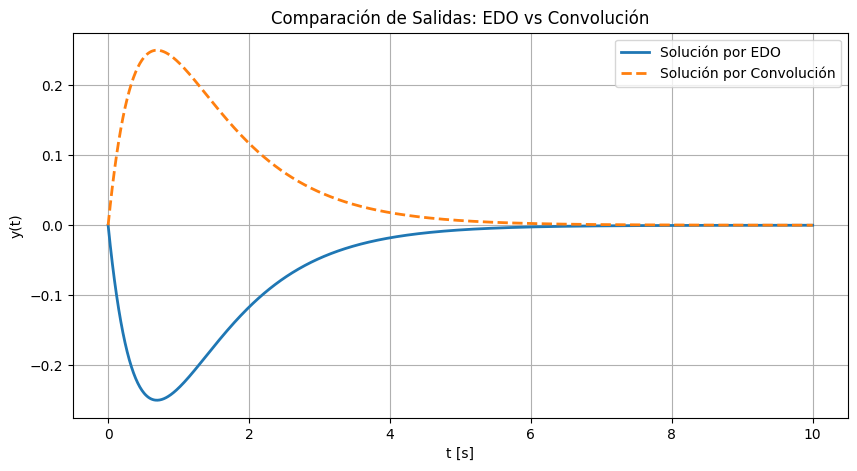

In [1]:
import sympy as sym
import matplotlib.pyplot as plt
import numpy as np

# Inicialización
t, tau = sym.symbols('t tau', real=True)
sym.init_printing()

# Entradas y funciones
x = sym.exp(-2*t) * sym.Heaviside(t)
h = sym.exp(-t) * sym.Heaviside(t)

# --- Solución por EDO (ya obtenida anteriormente)
y_edo = (sym.exp(-2*t) - sym.exp(-t)) * sym.Heaviside(t)

# --- Solución por convolución simbólica
conv_integral = sym.integrate(sym.exp(-2*tau) * h.subs(t, t - tau), (tau, 0, t))
y_conv = conv_integral

# --- Convertir a funciones numéricas
y_edo_func = sym.lambdify(t, y_edo, modules=['numpy'])
y_conv_func = sym.lambdify(t, y_conv, modules=['numpy'])

# --- Crear el dominio de tiempo
t_vals = np.linspace(0, 10, 1000)

# --- Evaluar las funciones
y_edo_vals = y_edo_func(t_vals)
y_conv_vals = y_conv_func(t_vals)

# --- Graficar
plt.figure(figsize=(10,5))
plt.plot(t_vals, y_edo_vals, label='Solución por EDO', linewidth=2)
plt.plot(t_vals, y_conv_vals, '--', label='Solución por Convolución', linewidth=2)
plt.title('Comparación de Salidas: EDO vs Convolución')
plt.xlabel('t [s]')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.show()


* Compruebe la solución $h(t)$ de la EDO cuando $x(t)=\delta(t)$ de manera manual. Tener en cuenta que $\frac{d}{dt} \epsilon(t) = \delta(t)$.


$$
\frac{d}{dt}y(t) + y(t) = x(t)
$$


$$
x(t) = \delta(t)
$$

---



$$
\frac{d}{dt}h(t) + h(t) = \delta(t)
$$

con condición inicial $h(0^-) = 0$, es:

$$
h(t) = e^{-t} \cdot u(t)
$$

---



$$
\frac{d}{dt}h(t) + h(t) = \delta(t)
$$

La solución general de esta ecuación tiene dos partes:

* **Parte homogénea**: solución de la ecuación sin el impulso:

  $$
  \frac{d}{dt}h(t) + h(t) = 0 \quad \Rightarrow \quad h_{\text{hom}}(t) = C \cdot e^{-t}
  $$

* **Parte particular**: debido al impulso $\delta(t)$, habrá una discontinuidad en $h(t)$ en $t = 0$, que se traduce en un **salto en la derivada**.


$$
\int_{-\varepsilon}^{+\varepsilon} \left( \frac{d}{dt}h(t) + h(t) \right) dt = \int_{-\varepsilon}^{+\varepsilon} \delta(t) dt
$$

La integral del segundo término da ≈ 0 porque $h(t)$ es continua y pequeña en un intervalo tan estrecho:

$$
\int_{-\varepsilon}^{+\varepsilon} \frac{d}{dt}h(t)\,dt + \underbrace{\int_{-\varepsilon}^{+\varepsilon} h(t)\,dt}_{\approx 0} = 1
$$

Por tanto:

$$
h(0^+) - h(0^-) = 1
$$

Dado que $h(0^-) = 0$ (condición inicial), entonces:

$$
h(0^+) = 1
$$



Sabemos que para $t > 0$, la solución debe ser de la forma:

$$
h(t) = C \cdot e^{-t} \cdot u(t)
$$

Ya vimos que $h(0^+) = C = 1$, entonces:

$$
h(t) = e^{-t} \cdot u(t)
$$

-

> La solución a la EDO $\frac{d}{dt}h(t) + h(t) = \delta(t)$, con condición inicial $h(0^-) = 0$, es:

$$
h(t) = e^{-t} \cdot u(t)
$$






* Comprobar la solución de la integral de convolución de manera manual. Tener en cuenta las funciones Heaviside.

Perfecto. Vamos ahora a **comprobar manualmente la solución de la integral de convolución**:

---

##  Datos del problema

Queremos calcular manualmente la salida del sistema lineal invariante en el tiempo (SLIT) usando la **integral de convolución**:

$$
y(t) = (x * h)(t) = \int_{0}^{t} x(\tau) \cdot h(t - \tau)\, d\tau
$$

donde:

* Entrada: $x(t) = e^{-2t} \cdot u(t)$
* Respuesta al impulso: $h(t) = e^{-t} \cdot u(t)$

---



Ambas señales son causales (multiplicadas por $u(t)$), por lo tanto la integral de convolución se reduce a:

$$
y(t) = \int_{0}^{t} e^{-2\tau} \cdot e^{-(t - \tau)} \, d\tau
$$

---



Multiplicamos los exponentes:

$$
e^{-2\tau} \cdot e^{-(t - \tau)} = e^{-2\tau} \cdot e^{-t + \tau} = e^{-t - \tau}
$$

Entonces la integral queda:

$$
y(t) = \int_0^t e^{-t - \tau} \, d\tau = e^{-t} \int_0^t e^{-\tau} \, d\tau
$$

La integral de $e^{-\tau}$ es:

$$
\int_0^t e^{-\tau} \, d\tau = \left[ -e^{-\tau} \right]_0^t = -e^{-t} + 1 = 1 - e^{-t}
$$

Entonces:

$$
y(t) = e^{-t} \cdot (1 - e^{-t}) = e^{-t} - e^{-2t}
$$



Recordando que las señales originales eran causales, entonces:

$$
y(t) = \left( e^{-2t} - e^{-t} \right) \cdot u(t)
$$

---



La salida manualmente obtenida por convolución es:

$$
\boxed{y(t) = (x * h)(t) = \left(e^{-2t} - e^{-t}\right) \cdot u(t)}
$$


---
